# **SymptoScan**

### 🐾 AI-based animal disease prediction system that analyzes animal health information and symptoms to support early disease screening.

## 1. Loading the datasets

In this part, we load the original animal disease dataset from Kaggle and also load the generated dataset that we will use later for comparison.

At this stage, we will not combine or change the datasets yet. We just want to check their sizes and understand how much data we have in each one.

The original dataset will be treated as the real data, while the generated dataset will be used separately to investigate whether adding synthetic data changes the model performance.

In [189]:
import warnings
import numpy as np #numpy
import pandas as pd #pandas
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset/animal_disease_prediction.csv")
df_generated = pd.read_csv("Dataset/generated_dataset.csv")
pd.set_option('display.width', 120)

warnings.filterwarnings('ignore')
print("Original Dataset from Kaggle\n",df.shape)
print("Generated Dataset by AI\n",df_generated.shape)

Original Dataset from Kaggle
 (431, 22)
Generated Dataset by AI
 (10031, 22)


In [190]:
df.info()

# Create a copy 
df_copy = df.copy()
df_generated_copy = df_generated.copy()

<class 'pandas.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Animal_Type         431 non-null    str    
 1   Breed               431 non-null    str    
 2   Age                 431 non-null    int64  
 3   Gender              431 non-null    str    
 4   Weight              431 non-null    float64
 5   Symptom_1           431 non-null    str    
 6   Symptom_2           431 non-null    str    
 7   Symptom_3           431 non-null    str    
 8   Symptom_4           431 non-null    str    
 9   Duration            431 non-null    str    
 10  Appetite_Loss       431 non-null    str    
 11  Vomiting            431 non-null    str    
 12  Diarrhea            431 non-null    str    
 13  Coughing            431 non-null    str    
 14  Labored_Breathing   431 non-null    str    
 15  Lameness            431 non-null    str    
 16  Skin_Lesions       

## 2. Data Preprocessing

In this part, we clean and prepare the data before training the models.

First, we check for and remove duplicate rows and remove extra spaces. We also check the data types and convert columns to the correct format.

We remove the Breed column because it has many different categories compared with the size of the real dataset. Keeping it could make the model learn very specific breed patterns instead of learning more general disease patterns.

We also check missing values and make sure the numerical and categorical features are in a suitable format for the models.

After cleaning the data, we check the dataset again to make sure the features and target column are ready for the next steps.

In [191]:
# Remove extra-spaces from the beginning and end of column names
df_copy.columns, df_generated_copy.columns = df_copy.columns.str.strip(), df_generated_copy.columns.str.strip()

In [192]:
# How many Animal type + Breed are there
print(df_copy[['Animal_Type','Breed']].nunique())
print("Animal_Type:",df_copy['Animal_Type'].unique())
print("---------")
print("Breed:",df_copy['Breed'].unique())

Animal_Type      8
Breed          120
dtype: int64
Animal_Type: <ArrowStringArray>
['Dog', 'Cat', 'Cow', 'Horse', 'Rabbit', 'Sheep', 'Goat', 'Pig']
Length: 8, dtype: str
---------
Breed: <ArrowStringArray>
[         'Labrador',           'Siamese',          'Holstein',            'Beagle',           'Persian',
      'Thoroughbred',   'German Shepherd',        'Maine Coon',           'Bulldog',            'Jersey',
 ...
        'Andalusian',             'Tunis',          'Red Poll',          'Pietrain',       'English Lop',
         'Blackface',   'Belted Galloway', 'Yorkshire Terrier',       'Rambouillet',     'Chester White']
Length: 120, dtype: str


In [193]:
# Remove breed from the both datasets
df_copy.drop(columns=['Breed'], inplace=True)
df_generated_copy.drop(columns=['Breed'], inplace=True)
print(df_copy.columns)

Index(['Animal_Type', 'Age', 'Gender', 'Weight', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Duration',
       'Appetite_Loss', 'Vomiting', 'Diarrhea', 'Coughing', 'Labored_Breathing', 'Lameness', 'Skin_Lesions',
       'Nasal_Discharge', 'Eye_Discharge', 'Body_Temperature', 'Heart_Rate', 'Disease_Prediction'],
      dtype='str')


In [194]:
# Check Missing Values
print(df_copy.isnull().sum())

Animal_Type           0
Age                   0
Gender                0
Weight                0
Symptom_1             0
Symptom_2             0
Symptom_3             0
Symptom_4             0
Duration              0
Appetite_Loss         0
Vomiting              0
Diarrhea              0
Coughing              0
Labored_Breathing     0
Lameness              0
Skin_Lesions          0
Nasal_Discharge       0
Eye_Discharge         0
Body_Temperature      0
Heart_Rate            0
Disease_Prediction    0
dtype: int64


In [195]:
df_copy[df_copy.duplicated]

,Animal_Type,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Duration,Appetite_Loss,...,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Disease_Prediction
421,Dog,4,Male,25.0,Fever,Lethargy,Appetite Loss,Vomiting,3 days,Yes,...,No,No,No,No,No,No,No,39.5°C,120,Parvovirus
422,Cat,2,Female,4.5,Coughing,Sneezing,Eye Discharge,Nasal Discharge,1 week,No,...,No,Yes,No,No,No,Yes,Yes,38.9°C,150,Upper Respiratory Infection
423,Cow,3,Female,600.0,Fever,Nasal Discharge,Labored Breathing,Coughing,5 days,Yes,...,No,Yes,Yes,No,No,Yes,No,40.1°C,90,Foot and Mouth Disease
424,Dog,1,Male,10.0,Diarrhea,Vomiting,Lethargy,Appetite Loss,2 days,Yes,...,Yes,No,No,No,No,No,No,39.2°C,130,Gastroenteritis
425,Cat,5,Male,3.8,Lethargy,Appetite Loss,Skin Lesions,No,2 weeks,Yes,...,No,No,No,No,Yes,No,No,38.7°C,160,Fungal Infection
426,Horse,6,Female,500.0,Coughing,Labored Breathing,Nasal Discharge,Fever,10 days,Yes,...,No,Yes,Yes,No,No,Yes,No,39.8°C,85,Equine Influenza
427,Dog,3,Female,30.0,Lameness,Fever,Skin Lesions,Lethargy,7 days,Yes,...,No,No,No,Yes,Yes,No,No,39.3°C,110,Lyme Disease
428,Cat,2,Male,6.0,Vomiting,Appetite Loss,Lethargy,Diarrhea,4 days,Yes,...,Yes,No,No,No,No,No,No,39.1°C,140,Intestinal Parasites
429,Dog,5,Male,23.0,Labored Breathing,Coughing,Nasal Discharge,Appetite Loss,6 days,Yes,...,No,Yes,Yes,No,No,Yes,No,40.0°C,115,Canine Distemper
430,Cow,4,Female,580.0,Lethargy,Decreased Milk Yield,Fever,No,8 days,Yes,...,No,No,No,No,No,No,No,39.6°C,70,Mastitis


In [196]:
# Remove Duplicated Rows
df_copy = df_copy.drop_duplicates()
print(df_copy.shape)

(421, 21)


In [197]:
# Fix features' datatype (Symptoms)
def fix_bool_features(df):
    bool_features = df[['Appetite_Loss', 'Vomiting', 'Diarrhea', 'Coughing', 'Labored_Breathing', 'Lameness',
           'Skin_Lesions', 'Nasal_Discharge', 'Eye_Discharge']]

    for feature in bool_features:
        df[feature] = df[feature].str.strip().str.lower().map({'yes': True, 'no': False})
        df.head()

    return df

#Change symptoms type on the both datasets
df_copy = fix_bool_features(df_copy)
df_generated_copy = fix_bool_features(df_generated_copy)


**Analysis of the Symptoms**: We analyze the four text-based symptom columns: Symptom_1 to Symptom_4.

We first check the values in each column to understand what kind of symptoms we have and how often they appear.

From this analysis, we found that some symptoms are already available in the existing Boolean columns, while some have different names but the same meaning. We also found some new symptoms that are not included in the existing Boolean columns.

For example, “Loss Of Appetite”, “Reduced Appetite”, and “Appetite Loss” describe the same symptom. We also found similar cases for reduced milk production, reduced wool production, and swelling.

Because of this, we decided to standardize these symptoms instead of keeping the same information in different forms.

In [198]:
# Analysis all the Symptoms columns
# Distribution of Symptoms across Symptom_1 to Symptom_4
print(df_copy['Symptom_1'].value_counts(),"\n")
print(df_copy['Symptom_2'].value_counts(),"\n")
print(df_copy['Symptom_3'].value_counts(),"\n")
print(df_copy['Symptom_4'].value_counts(),"\n")

Symptom_1
Coughing                139
Vomiting                 61
Lameness                 54
Lethargy                 50
Sneezing                 33
Nasal Discharge          23
Fever                    14
Diarrhea                 11
Appetite Loss             8
Swollen Joints            8
Eye Discharge             7
Weight Loss               7
Labored Breathing         2
Loss of Appetite          2
Skin Lesions              1
Decreased Milk Yield      1
Name: count, dtype: int64 

Symptom_2
Loss of Appetite           155
Diarrhea                    43
Nasal Discharge             40
Vomiting                    35
Lethargy                    22
Swollen Legs                21
Coughing                    20
Fever                       18
Labored Breathing           12
Appetite Loss               11
Swollen Joints              11
Eye Discharge                9
Dehydration                  6
Sneezing                     5
Weight Loss                  4
Lameness                     3
Decrease

The idea here is to convert the text symptoms into the existing Boolean symptom features so that all symptoms have a consistent format.

First, we clean the text by removing extra spaces and converting everything to lowercase. Then, we create a mapping for symptoms that have different names but the same meaning.

For each row, we check **Symptom_1 to Symptom_4** and mark the corresponding Boolean feature as `True` if the symptom is found. For example, **“Loss of Appetite”, “Reduced Appetite”, and “Appetite Loss”** are all mapped to `Appetite_Loss`.

We also add the new symptoms that we found, such as **Fever, Lethargy, Sneezing, Weight Loss, and Dehydration**.

After mapping the symptoms, we remove the original `Symptom_1` to `Symptom_4` columns because their information has already been converted into the standardized Boolean features. This gives us a cleaner and more consistent set of symptom features for the models.


In [199]:
# Mapping ['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4'] into the bool features
# Assign all the Symptoms into bool features
symptom_cols = ['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4']

def standardize_symptoms(df):
    # 1. Clean raw text columns
    for col in symptom_cols:
        df[col] = df[col].astype(str).str.strip().str.lower()

    # 2. Synonym map
    synonym_map = {
        'Appetite_Loss': ['appetite loss', 'loss of appetite', 'reduced appetite', 'decreased appetite'],
        'Reduced_Milk': ['reduced milk production', 'decreased milk yield'],
        'Reduced_Wool': ['reduced wool production', 'reduced wool growth'],
        'Swelling': ['swollen joints', 'swollen legs', 'swelling', 'reduced mobility'],
        'Fever': ['fever'],
        'Lethargy': ['lethargy'],
        'Weight_Loss': ['weight loss'],
        'Dehydration': ['dehydration'],
        'Sneezing': ['sneezing']
    }

    # 3. Create normalized binary symptom columns
    for std_name, variations in synonym_map.items():
        # Check if any variation appears across Symptom_1 to Symptom_4 for each row
        df[std_name] = df[symptom_cols].apply(lambda row: row.isin(variations).any(), axis=1).astype(bool)

    # 4. Drop original symptom columns after normalization
    df.drop(columns=symptom_cols, inplace=True)

    return df

df_copy = standardize_symptoms(df_copy)
df_generated_copy = standardize_symptoms(df_generated_copy)

print(df_copy.columns)

Index(['Animal_Type', 'Age', 'Gender', 'Weight', 'Duration', 'Appetite_Loss', 'Vomiting', 'Diarrhea', 'Coughing',
       'Labored_Breathing', 'Lameness', 'Skin_Lesions', 'Nasal_Discharge', 'Eye_Discharge', 'Body_Temperature',
       'Heart_Rate', 'Disease_Prediction', 'Reduced_Milk', 'Reduced_Wool', 'Swelling', 'Fever', 'Lethargy',
       'Weight_Loss', 'Dehydration', 'Sneezing'],
      dtype='str')


In [200]:
# Clean Body Temperature values and convert to float
def clean_body_temperature(df):
    df['Body_Temperature'] = (
        df['Body_Temperature']
        .astype(str)
        .str.replace('°C', '', regex=False)
        .str.strip()
        .astype(float)
    )
    return df

df_copy = clean_body_temperature(df_copy)
df_generated_copy = clean_body_temperature(df_generated_copy)

df_copy[['Body_Temperature']]


,Body_Temperature
0,39.5
1,38.9
2,40.1
3,39.2
4,38.7
...,...
416,39.2
417,39.2
418,39.1
419,39.4


In [201]:
#Convert Duration text into numeric days
def duration_to_days(value):
    value = str(value).lower().strip()
    num = int(''.join(filter(str.isdigit, value)))
    if 'week' in value:
        return num * 7
    elif 'month' in value:
        return num * 30
    else:  # days
        return num

# Drop Duration column after creating Duration_Days
def clean_duration(df):
    df['Duration_Days'] = df['Duration'].apply(duration_to_days)
    df.drop(columns=['Duration'], inplace=True)
    return df

df_copy = clean_duration(df_copy)
df_generated_copy = clean_duration(df_generated_copy)

## 3. Data Visualization

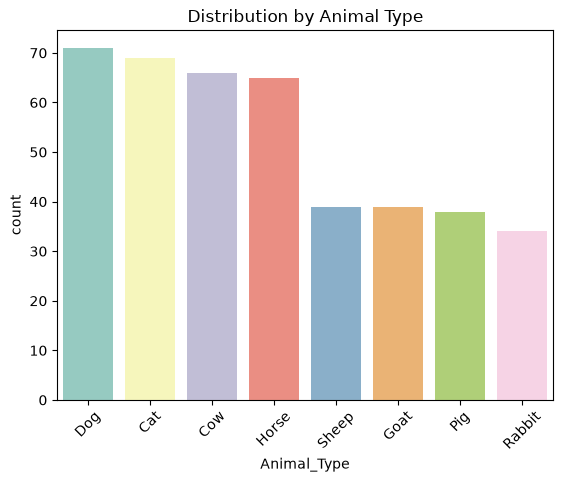

In [202]:
# The Expected Animal Types
sns.countplot(
    data=df_copy,
    x='Animal_Type',
    order=df_copy['Animal_Type'].value_counts().index ,palette='Set3')
plt.title("Distribution by Animal Type")
plt.xticks(rotation=45)
plt.savefig('Visualization-image/animal_type_distribution.png', dpi=300)
plt.show()

**Animal Type Distribution**

This plot shows the distribution of animal types in the original dataset. Dogs and cats have the highest number of records, while rabbits have the lowest. The distribution is not completely balanced, so we consider this when evaluating the models.

Number of unique diseases: 139


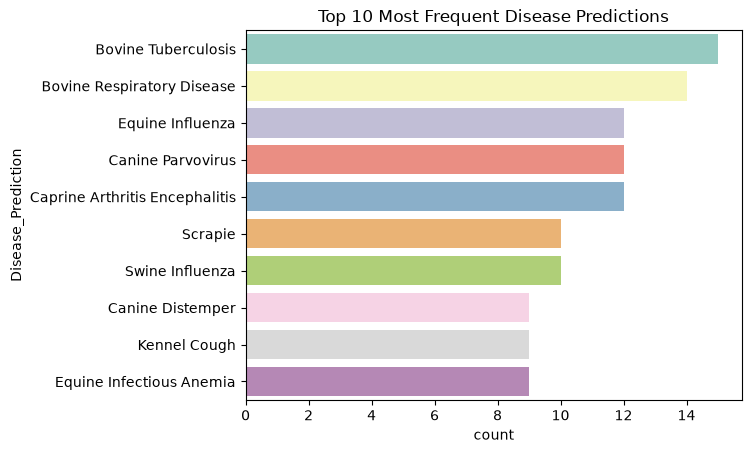

In [203]:
print("Number of unique diseases:", df_copy['Disease_Prediction'].nunique())
sns.countplot(
    data=df_copy,
    y ='Disease_Prediction',
    order=df_copy['Disease_Prediction'].value_counts().head(10).index,palette='Set3')

plt.title("Top 10 Most Frequent Disease Predictions")
plt.savefig('Visualization-image/most_frequent_disease.png', dpi=300)
plt.show()

The dataset contains **139 different disease classes**. The top 10 diseases have different numbers of records, showing that the classes are not perfectly balanced. This is important because diseases with fewer records may be harder for the models to learn and predict correctly.


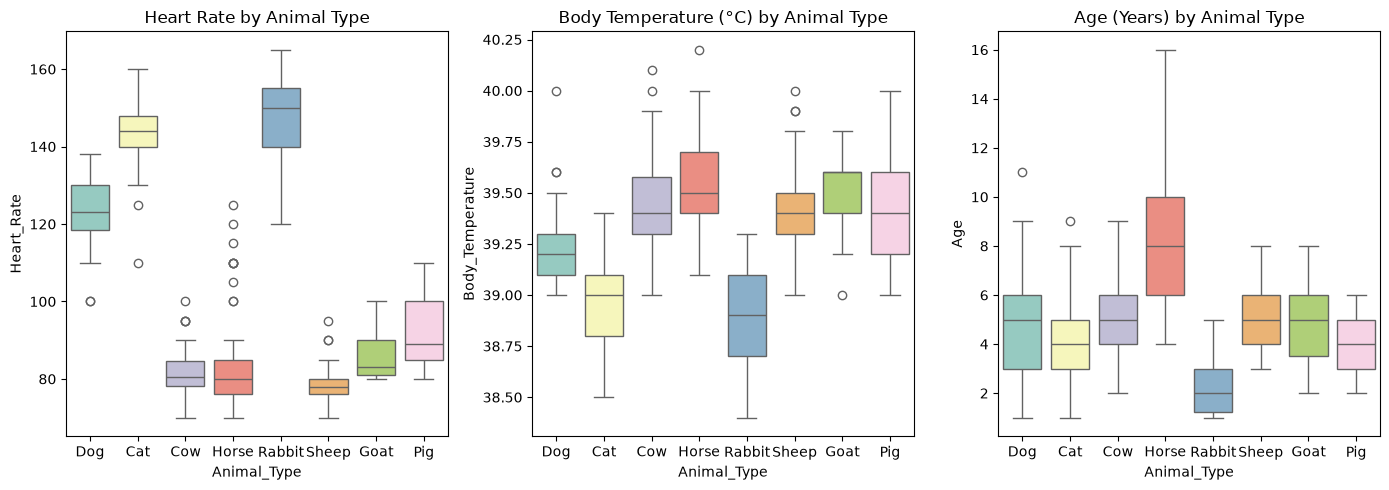

In [204]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
sns.boxplot(data=df_copy, x='Animal_Type', y='Heart_Rate', palette='Set3', ax=axes[0])
axes[0].set_title('Heart Rate by Animal Type')

sns.boxplot(data=df_copy, x='Animal_Type', y='Body_Temperature', palette='Set3', ax=axes[1])
axes[1].set_title('Body Temperature (°C) by Animal Type')

sns.boxplot(data=df_copy, x='Animal_Type', y='Age', palette='Set3', ax=axes[2])
axes[2].set_title('Age (Years) by Animal Type')

plt.tight_layout()
plt.savefig('Visualization-image/vitals_distribution.png', dpi=300)
plt.show()

The boxplots show differences in heart rate, body temperature, and age across animal types. Some outliers are visible, especially in heart rate. These values were kept because they may represent genuine clinical cases rather than data-entry errors. Removing them could remove useful information about animals with unusual health conditions.

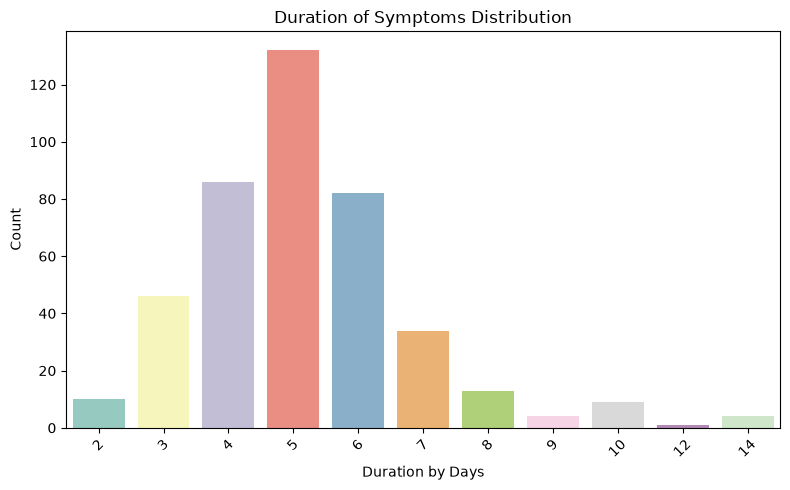

In [205]:
# Symptom Duration Distribution
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_copy,
    x='Duration_Days',
    palette='Set3',
    order=df_copy['Duration_Days'].value_counts().sort_index().index
)
plt.title('Duration of Symptoms Distribution')
plt.xlabel('Duration by Days')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig('Visualization-image/duration_of_symptoms_distribution.png', dpi=300)
plt.tight_layout()
plt.show()

The symptom duration varies across the records, with some durations occurring more frequently than others. This feature provides information about how long the animal has experienced symptoms and may help the model distinguish between different disease patterns.

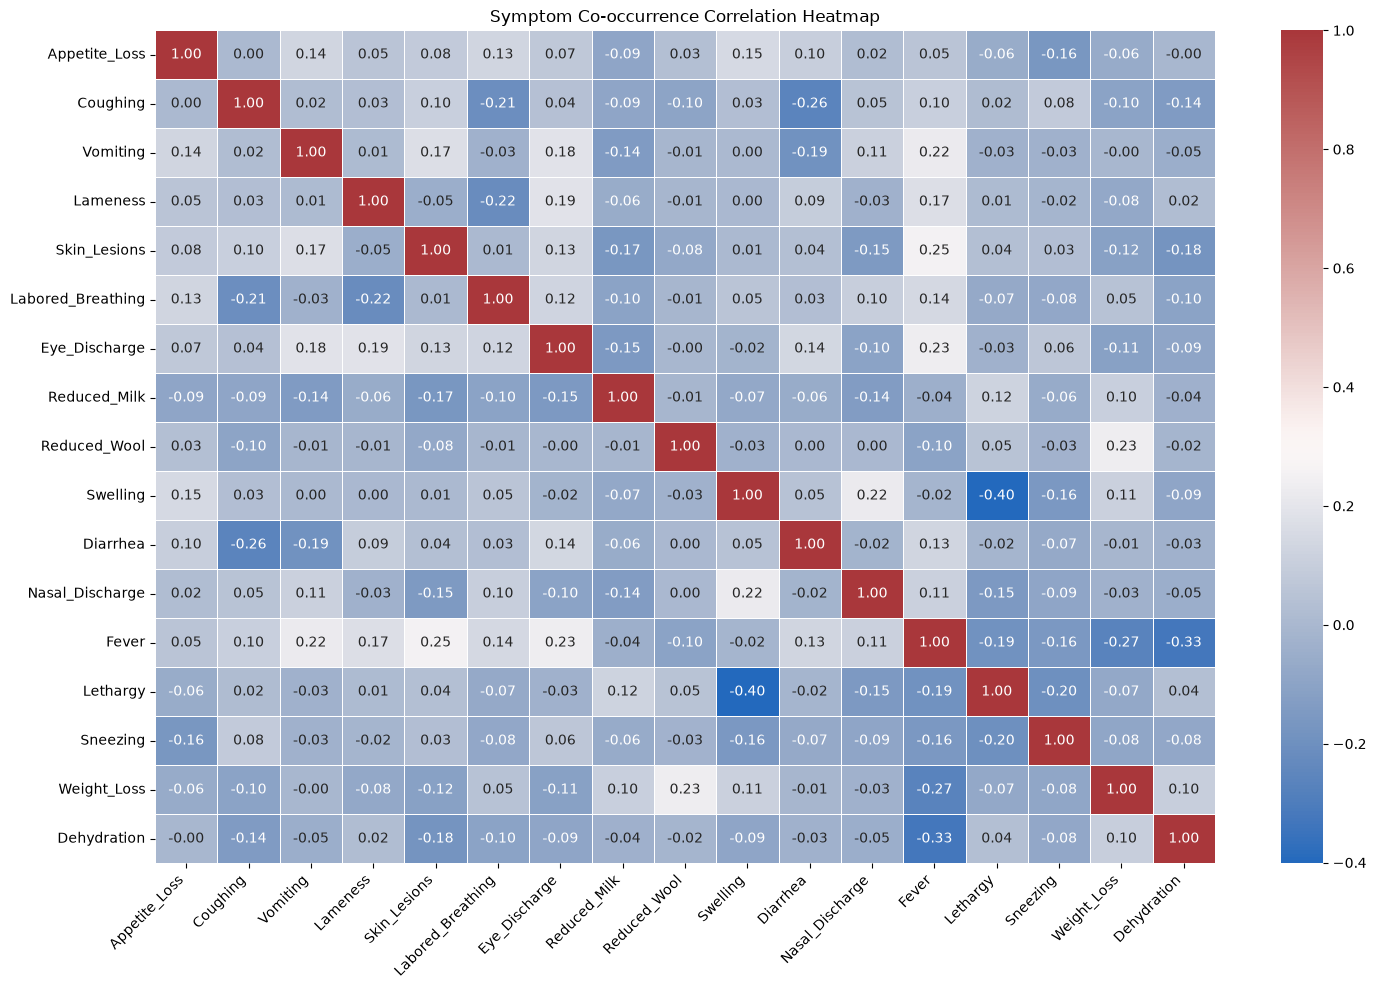

In [206]:
# Symptom Co-occurrence Correlation Heatmap
symptom_cols = ['Appetite_Loss', 'Coughing', 'Vomiting', 'Lameness',
                'Skin_Lesions', 'Labored_Breathing', 'Eye_Discharge','Reduced_Milk','Reduced_Wool','Swelling',
                'Diarrhea', 'Nasal_Discharge','Fever','Lethargy', 'Sneezing','Weight_Loss', 'Dehydration']
symptom_df = (df_copy[symptom_cols] == True).astype(int)
corr_matrix = symptom_df.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', fmt='.2f', linewidths=0.5)
plt.title('Symptom Co-occurrence Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.savefig('Visualization-image/symptoms_heatmap.png', dpi=300)
plt.tight_layout()
plt.show()

The heatmap shows the correlation between different symptoms. Some symptoms have stronger positive correlations, meaning they tend to appear together in the same records. Other symptoms have weak or near-zero correlations, suggesting they occur more independently. This helps us understand relationships between symptoms before training the classification models.

## 4. Feature Engineering

In this part, we prepare the cleaned data so it can be used for machine learning models.

First, we create a copy of the cleaned dataset so that we can make changes without affecting the previous version. We also separate the features into three groups: **symptoms, categorical features, and numerical features**.

The symptom columns are converted from Boolean values (`True`/`False`) into numerical values (`1`/`0`). This makes them easier for the machine learning models to use. Missing symptom values are also treated as `False`, meaning that the symptom is not recorded for that patient.

The categorical features are **Animal_Type** and **Gender**, while the numerical features include **Age, Weight, Heart_Rate, Body_Temperature, and Duration_Days**.

In [207]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

df_fe = df_copy.copy()

symptoms = ['Appetite_Loss', 'Vomiting', 'Diarrhea', 'Coughing', 'Labored_Breathing','Lameness', 'Skin_Lesions', 'Nasal_Discharge', 'Eye_Discharge','Reduced_Milk', 'Reduced_Wool', 'Swelling', 'Fever', 'Lethargy',
'Weight_Loss', 'Dehydration', 'Sneezing']

#Converted the symptoms into numeric
df_fe[symptoms] = df_fe[symptoms].fillna(False).astype(int)
print("dtypes:", df_fe[symptoms].dtypes.unique())

cat_features = ["Animal_Type","Gender"]
num_features = ['Age', 'Weight', 'Heart_Rate', 'Body_Temperature', 'Duration_Days']

dtypes: [dtype('int64')]


Next, we check the number of records for each disease. This is important because the dataset contains many different disease classes, but some diseases have only a few records. We check the number of diseases, the number of records per disease, and especially the diseases that have only one record.

In [208]:
# Check the number of records for each disease
disease_counts = df_fe["Disease_Prediction"].value_counts()

print("\nDisease counts:", disease_counts)
print("\nDiseases with only 1 record:", disease_counts[disease_counts == 1])
print("\nNumber of diseases with only 1 record:",(disease_counts == 1).sum())


Disease counts: Disease_Prediction
Bovine Tuberculosis                15
Bovine Respiratory Disease         14
Equine Influenza                   12
Canine Parvovirus                  12
Caprine Arthritis Encephalitis     12
                                   ..
Goat Pox                            1
Porcine Epidemic Diarrhea Virus     1
Canine Infectious Hepatitis         1
Feline Panleukopenia Virus          1
Porcine Circovirus Disease          1
Name: count, Length: 139, dtype: int64

Diseases with only 1 record: Disease_Prediction
Fungal Infection                                 1
Lyme Disease                                     1
Intestinal Parasites                             1
Strangles                                        1
Tick-Borne Disease                               1
Arthritis                                        1
Heartworm Disease                                1
Equine Viral Arteritis                           1
Conjunctivitis                                   1

In [209]:
print("\nDisease classes:", df_fe["Disease_Prediction"].nunique())
print("\nNumber of diseases by record count:")
print(disease_counts.value_counts().sort_index())


Disease classes: 139

Number of diseases by record count:
count
1     60
2     27
3     15
4      9
5      6
6      4
7      4
8      4
9      3
10     2
12     3
14     1
15     1
Name: count, dtype: int64


We also check the disease names to find labels that may refer to the same disease but are written differently. For example, we found different versions of **Bluetongue**, so we inspected these labels before deciding how to standardize them.

In [210]:
# Sort disease, check similarity
disease_names = sorted(df_fe["Disease_Prediction"].unique())
for disease in disease_names:
    print(disease)

Actinobacillus Pleuropneumonia
Actinobacillus Suis
African Swine Fever
Allergic Rhinitis
Arthritis
Blue Tongue
Blue Tongue Disease
Blue Tongue Virus
Bluetongue
Bluetongue Virus
Bordetella Infection
Bovine Coccidiosis
Bovine Influenza
Bovine Johne's Disease
Bovine Leukemia Virus
Bovine Mastitis
Bovine Parainfluenza
Bovine Pneumonia
Bovine Respiratory Disease
Bovine Respiratory Disease Complex
Bovine Respiratory Syncytial Virus
Bovine Tuberculosis
Bovine Viral Diarrhea
Canine Cough
Canine Distemper
Canine Flu
Canine Heartworm Disease
Canine Hepatitis
Canine Infectious Hepatitis
Canine Influenza
Canine Leptospirosis
Canine Parvovirus
Caprine Arthritis
Caprine Arthritis Encephalitis
Caprine Arthritis Encephalitis Virus
Caprine Pleuropneumonia
Caprine Respiratory Disease
Caprine Viral Arthritis
Caseous Lymphadenitis
Chlamydia in Sheep
Chronic Bronchitis
Coccidiosis
Conjunctivitis
Contagious Abortion
Contagious Ecthyma
Cryptosporidiosis
Degenerative Joint Disease
Distemper
Enteritis
Equine A

In [211]:
# Only for checking similar diseases
bluetooth_rows = df_fe[df_fe["Disease_Prediction"].str.contains("Blue Tongue|Bluetongue",case=False,na=False)]
print(bluetooth_rows["Disease_Prediction"].value_counts())
print(bluetooth_rows[["Disease_Prediction", "Animal_Type", "Gender"]].to_string(index=False))

Disease_Prediction
Bluetongue             5
Blue Tongue Virus      2
Bluetongue Virus       2
Blue Tongue            1
Blue Tongue Disease    1
Name: count, dtype: int64
 Disease_Prediction Animal_Type Gender
  Blue Tongue Virus       Sheep Female
        Blue Tongue       Sheep Female
   Bluetongue Virus       Sheep   Male
Blue Tongue Disease       Sheep   Male
         Bluetongue       Sheep   Male
         Bluetongue       Sheep Female
  Blue Tongue Virus       Sheep   Male
         Bluetongue       Sheep   Male
   Bluetongue Virus       Sheep   Male
         Bluetongue       Sheep Female
         Bluetongue       Sheep   Male


After checking the disease names, we create a mapping for labels that have the same meaning but different names. For example, **“Blue Tongue”, “Blue Tongue Disease”, and “Blue Tongue Virus”** are standardized to **“Bluetongue”**.

Finally, we apply this mapping to the disease target column and compare the number of disease classes before and after standardization. We also check the new distribution to see how many records are available for each standardized disease.

This step helps us reduce duplicate label names while keeping the original disease information more consistent for the machine learning models.

In [212]:
disease_mapping = {
    'Foot-and-Mouth Disease': 'Foot and Mouth Disease',
    'Blue Tongue': 'Bluetongue',
    'Blue Tongue Virus': 'Bluetongue',
    'Blue Tongue Disease': 'Bluetongue',
    'Bluetongue Virus': 'Bluetongue',
    'Canine Flu': 'Canine Influenza',
    'Swine Flu': 'Swine Influenza',
    'Scrapie Disease': 'Scrapie',
    'Rabbit Hemorrhagic Disease': 'Rabbit Viral Hemorrhagic Disease',
    'Feline Chlamydia': 'Feline Chlamydiosis',
    'Canine Infectious Hepatitis': 'Canine Hepatitis',
    'Bovine Johne\'s Disease': "Johne's Disease",
    'Equine Influenza Virus': 'Equine Influenza',
    'Caprine Arthritis Encephalitis Virus': 'Caprine Arthritis Encephalitis',
}

# Additional duplicate labels, verified 1-to-1 with Animal_Type
# (see markdown above for how each of these was checked before merging)

duplicate_label_map = {
    'Bovine Respiratory Disease Complex': 'Bovine Respiratory Disease',   
    # Cow only
    'Bovine Mastitis': 'Mastitis',                                        
    # Cow only
    'Canine Parvovirus': 'Parvovirus',                                    
    # Dog only
    'Feline Panleukopenia': 'Panleukopenia',                              
    # Cat only
    'Feline Panleukopenia Virus': 'Panleukopenia',                        
    # Cat only
    'Equine Osteoarthritis': 'Equine Arthritis',                          
    # Horse only (NOT merged with Dog's 'Arthritis')
    'Distemper': 'Canine Distemper',                                      
    # Dog only
    'Leptospirosis': 'Canine Leptospirosis',                              
    # Dog only
    'Laminitis': 'Equine Laminitis',                                      
    # Horse only
    'Tuberculosis': 'Bovine Tuberculosis',                               
    # Cow only
    'Respiratory Syncytial Virus': 'Bovine Respiratory Syncytial Virus',  
    # Cow only
    'West Nile Virus': 'Equine West Nile Virus',                          
    # Horse only
}
disease_mapping.update(duplicate_label_map)

In [213]:
df_clean_labels = df_fe.copy()

df_clean_labels["Disease_Prediction"] = (df_clean_labels["Disease_Prediction"]
    .replace(disease_mapping))

print("Original disease classes:", df_fe["Disease_Prediction"].nunique())
print("After label standardization:",df_clean_labels["Disease_Prediction"].nunique())

Original disease classes: 139
After label standardization: 113


In [214]:
# Check again after label cleaning 
clean_counts = df_clean_labels["Disease_Prediction"].value_counts()
print("Number of diseases by record count:\n",clean_counts.value_counts().sort_index())

print("\nDiseases with only 1 record:",clean_counts[clean_counts == 1])

Number of diseases by record count:
 count
1     47
2     19
3     10
4      7
5      3
6      4
7      6
8      3
9      4
11     3
12     2
13     1
14     1
16     1
17     1
20     1
Name: count, dtype: int64

Diseases with only 1 record: Disease_Prediction
Fungal Infection                                 1
Lyme Disease                                     1
Intestinal Parasites                             1
Strangles                                        1
Tick-Borne Disease                               1
Arthritis                                        1
Heartworm Disease                                1
Equine Viral Arteritis                           1
Conjunctivitis                                   1
Equine Piroplasmosis                             1
Chronic Bronchitis                               1
Equine Pneumonia                                 1
Cryptosporidiosis                                1
Bordetella Infection                             1
Inflammatory Bowel Disea

Some disease classes have only one or two records, which is not enough to properly split the data between training and testing. Keeping these very small classes could also make the evaluation less reliable.

So, we create a test_pool that contains only diseases with at least 3 records.


In [215]:
# Keep diseases with at least 3 real records
# test_pool >> contains the final result so far
test_pool = df_clean_labels[
    df_clean_labels["Disease_Prediction"].isin(
        clean_counts[clean_counts >= 3].index
    )
].copy()

print("Test pool shape:", test_pool.shape)
print("Number of disease classes:",
      test_pool["Disease_Prediction"].nunique())

print("\nDisease counts in test pool:")
print(test_pool["Disease_Prediction"].value_counts().sort_values())

Test pool shape: (336, 25)
Number of disease classes: 47

Disease counts in test pool:
Disease_Prediction
Swine Fever                            3
Equine Rhinopneumonitis                3
Coccidiosis                            3
Porcine Epidemic Diarrhea              3
Rabbit Syphilis                        3
Swine Erysipelas                       3
Equine Protozoal Myeloencephalitis     3
Equine Encephalomyelitis               3
Feline Asthma                          3
Equine West Nile Virus                 3
Upper Respiratory Infection            4
Bovine Viral Diarrhea                  4
Feline Upper Respiratory Infection     4
Canine Hepatitis                       4
Caprine Respiratory Disease            4
Pancreatitis                           4
Bovine Respiratory Syncytial Virus     4
Caprine Pleuropneumonia                5
Pasteurellosis                         5
Equine Laminitis                       5
Equine Arthritis                       6
Myxomatosis                      

## 5. Train-Test Split and Feature Encoding

We split the real data into a training set and a test set. We use **70% for training and 30% for testing**. The test set contains only real records and will be kept separate so we can use it later to evaluate how well the models perform on real data. Next, we prepare the features for the machine learning models.

**Numerical features**, fill any missing values using the median and then apply standard scaling.

**Categorical features**, fill missing values using the most frequent value and convert the categories into numerical columns using One-Hot Encoding.

The symptom features are already converted into `0` and `1`, so we can pass them directly to the models.
Finally, we use `LabelEncoder` to convert the disease names into numerical labels.

In [216]:
# X,Y training + features encoding
# Split the real evaluation pool into training and test sets
real_train, real_test = train_test_split(
    test_pool,
    test_size=0.30,
    random_state=42,
    stratify=test_pool["Disease_Prediction"]
)

print("Real evaluation training set:", real_train.shape)
print("Real-only test set:", real_test.shape)

# Numerical preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features),
    ("symptoms", "passthrough", symptoms)])

Real evaluation training set: (235, 25)
Real-only test set: (101, 25)


In [217]:
target_encoder = LabelEncoder()

# Encode the disease labels
y_real_train = target_encoder.fit_transform(real_train["Disease_Prediction"])
y_real_test = target_encoder.transform(real_test["Disease_Prediction"])

# Select the same features used by the models
X_real_train = real_train[cat_features + num_features + symptoms]
X_real_test = real_test[cat_features + num_features + symptoms]

print("Real training X shape:", X_real_train.shape)
print("Real test X shape:", X_real_test.shape)
print("Real training classes:", len(np.unique(y_real_train)))
print("Real test classes:", len(np.unique(y_real_test)))

Real training X shape: (235, 24)
Real test X shape: (101, 24)
Real training classes: 47
Real test classes: 47


## 6. Model Training and Evaluation

We train three different classification models: **Logistic Regression (LR), Random Forest (RF), and XGBoost (XGB)**.

For the evaluation, we use **Accuracy, Macro Precision, Macro Recall, and Macro F1-score**. We use the macro average because we have many disease classes with different numbers of records, so we want each disease class to have equal importance in the evaluation.


### 6.1 Experiment 1

In this part, we train each model using the **real training data only** and then use the same untouched **real test set** to make predictions.

This experiment gives us a baseline for how the models perform using only the original dataset.

In [218]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    'LR': Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(max_iter=1000))]),

    'RF': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1))
    ]),

    'XGB': Pipeline([
        ('prep', preprocessor),
        ('model', XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            eval_metric='mlogloss',
            random_state=42))
    ])
}

In [219]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_real_train, y_real_train)
    y_pred = model.predict(X_real_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_real_test, y_pred),
        "Precision": precision_score( y_real_test, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_real_test, y_pred, average="macro", zero_division=0),
        "F1": f1_score(y_real_test, y_pred, average="macro", zero_division=0)
    })

results_df = pd.DataFrame(results)

print("\nTest results:")
print(results_df)

Training LR...
Training RF...
Training XGB...

Test results:
  Model  Accuracy  Precision    Recall        F1
0    LR  0.306931   0.172163  0.207447  0.169237
1    RF  0.346535   0.212513  0.251773  0.214235
2   XGB  0.267327   0.188045  0.230496  0.185191


From the results, we can see that all three models are able to learn from the real data, but their performance is low.

Random Forest (RF) achieved the highest results among the three models, with 34.6% accuracy and a 0.214 Macro F1-score. Logistic Regression (LR) achieved 30.7% accuracy and a 0.169 Macro F1-score, while XGBoost (XGB) achieved 26.7% accuracy and a 0.185 Macro F1-score.

The lower performance is understandable because we have many disease classes but only a small number of records for each disease. Some diseases have only a few records, which makes it difficult for the models to learn clear patterns.

### 6.2 Experiment 2

#### 6.2.1 Preparing the Generated Data

We start looking at the AI-generated dataset before adding it to the real training data.

First, we check the generated dataset and look at the most common diseases to understand how the generated data is distributed.

Then, we standardize the disease names using the same mapping that we used for the real dataset. This makes sure that the disease labels have the same names in both datasets.


In [220]:
print("Generated dataset shape:", df_generated.shape)
print("Generated diseases:", df_generated["Disease_Prediction"].nunique())
print(df_generated["Disease_Prediction"].value_counts().head(10))

Generated dataset shape: (10031, 22)
Generated diseases: 139
Disease_Prediction
Pneumonia                      168
Ringworm                       156
Gastroenteritis                153
Upper Respiratory Infection    147
Pasteurellosis                 147
Coccidiosis                    140
Foot and Mouth Disease         136
Foot-and-Mouth Disease         131
Pancreatitis                   118
Caseous Lymphadenitis          117
Name: count, dtype: int64


In [221]:
df_generated_clean = df_generated_copy.copy()

df_generated_clean["Disease_Prediction"] = (
    df_generated_clean["Disease_Prediction"]
    .replace(disease_mapping))

We keep only the generated records for diseases that are also available in our real evaluation pool. This is important because we want to compare the models using the same disease classes.

Finally, instead of adding all the generated records, we take **15 records from each disease class**. This gives us a controlled and balanced sample of generated data rather than allowing diseases with a large number of generated records to dominate the training data.

In [222]:
usable_diseases = (test_pool["Disease_Prediction"].unique())

generated_usable = df_generated_clean[df_generated_clean["Disease_Prediction"].isin(usable_diseases)].copy()

print("Generated usable shape:", generated_usable.shape)
print("Generated usable diseases:",generated_usable["Disease_Prediction"].nunique())

Generated usable shape: (5387, 25)
Generated usable diseases: 47


In [223]:
print(generated_usable["Disease_Prediction"].value_counts().sort_values())

Disease_Prediction
Feline Leukemia Virus                  48
Bovine Viral Diarrhea                  57
Equine Encephalomyelitis               59
Equine Infectious Anemia               59
Swine Fever                            59
Equine Rhinopneumonitis                61
Rabbit Syphilis                        62
Caprine Respiratory Disease            64
Actinobacillus Pleuropneumonia         65
Feline Herpesvirus                     65
Swine Erysipelas                       66
Feline Calicivirus                     67
Feline Infectious Peritonitis          72
Feline Upper Respiratory Infection     72
Feline Asthma                          72
Equine Protozoal Myeloencephalitis     73
Equine Herpesvirus                     74
Porcine Epidemic Diarrhea              75
Myxomatosis                            76
Kennel Cough                           79
Caprine Pleuropneumonia                80
Pancreatitis                          118
Equine Influenza                      122
Rabbit Viral He

In [224]:
generated_sample = (
    generated_usable
    .groupby("Disease_Prediction", group_keys=False)
    .sample(n=15, random_state=42)
    .reset_index(drop=True)
)

print("Generated sample shape:", generated_sample.shape)
print(generated_sample["Disease_Prediction"].value_counts())

Generated sample shape: (705, 25)
Disease_Prediction
Actinobacillus Pleuropneumonia        15
Bluetongue                            15
Bovine Respiratory Disease            15
Bovine Respiratory Syncytial Virus    15
Bovine Tuberculosis                   15
Bovine Viral Diarrhea                 15
Canine Distemper                      15
Canine Hepatitis                      15
Canine Leptospirosis                  15
Caprine Arthritis Encephalitis        15
Caprine Pleuropneumonia               15
Caprine Respiratory Disease           15
Coccidiosis                           15
Equine Arthritis                      15
Equine Encephalomyelitis              15
Equine Herpesvirus                    15
Equine Infectious Anemia              15
Equine Influenza                      15
Equine Laminitis                      15
Equine Protozoal Myeloencephalitis    15
Equine Rhinopneumonitis               15
Equine West Nile Virus                15
Feline Asthma                         15
Feli

#### 6.2.2 Training with Original + Generated Data

We combine the real training data with the selected AI-generated records. We only add the generated records to `real_train`, so the test set remains untouched.

Then, we check the number of records in both datasets and make sure that the real and generated data have the same structure before training the models.

Also, we prepare `X_combined` and `y_combined` using the same features and disease-label encoding that we used in Experiment 1. We then train the same three models using the combined training data and test them on **exactly the same real test set**.




In [225]:
real_train_for_combined = real_train.copy()

combined_train = pd.concat([real_train_for_combined,generated_sample],ignore_index=True)

print("Combined training shape:", combined_train.shape)
print("Real training records:", len(real_train_for_combined))
print("Generated records:", len(generated_sample))

Combined training shape: (940, 25)
Real training records: 235
Generated records: 705


In [226]:
X_combined = combined_train[cat_features + num_features + symptoms]
y_combined = target_encoder.transform(combined_train["Disease_Prediction"])


print("Combined X shape:", X_combined.shape)
print("Combined y shape:", y_combined.shape)

Combined X shape: (940, 24)
Combined y shape: (940,)


In [227]:
# Just checking their columns
print("Real training columns:", len(real_train.columns))
print("Generated columns:", len(generated_sample.columns))
print("Combined columns:", len(combined_train.columns))

print("\nColumns only in real training:")
print(sorted(set(real_train.columns) - set(generated_sample.columns)))

print("\nColumns only in generated data:")
print(sorted(set(generated_sample.columns) - set(real_train.columns)))

Real training columns: 25
Generated columns: 25
Combined columns: 25

Columns only in real training:
[]

Columns only in generated data:
[]


In [228]:
combined_results = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_combined, y_combined)

    # Test ONLY on the same real test set
    y_pred = model.predict(X_real_test)

    combined_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_real_test, y_pred),
        "Precision": precision_score(y_real_test, y_pred,average="macro",zero_division=0),
        "Recall": recall_score(y_real_test, y_pred,average="macro",zero_division=0),
        "F1": f1_score(y_real_test, y_pred,average="macro",zero_division=0)
    })

combined_results_df = pd.DataFrame(combined_results)

print("\nReal + Generated training results:")
print(combined_results_df)

Training LR...
Training RF...
Training XGB...

Real + Generated training results:
  Model  Accuracy  Precision    Recall        F1
0    LR  0.594059   0.573936  0.651064  0.580556
1    RF  0.732673   0.655978  0.705319  0.659980
2   XGB  0.643564   0.596302  0.641489  0.591996


We can see that the performance of all three models improved compared with Experiment 1.

Random Forest (RF) achieved the highest results among the three models, with 73.2% accuracy and a 0.659 Macro F1-score. XGBoost (XGB) achieved 64.4% accuracy and a 0.592 Macro F1-score, while Logistic Regression (LR) achieved 59.4% accuracy and a 0.581 Macro F1-score.

This improvement is noticeable, especially for Random Forest. This suggests that the generated data is helping the models learn more patterns from the available training data.


## 7. Comparison Table

In [229]:
# Add experiment names
results_df["Experiment"] = "Real Only"
combined_results_df = pd.DataFrame(combined_results)
combined_results_df["Experiment"] = "Real + Generated"

# Combine both experiments
experiment_comparison = pd.concat(
    [results_df, combined_results_df],
    ignore_index=True)

experiment_comparison = experiment_comparison[
    ["Experiment", "Model", "Accuracy", "Precision", "Recall", "F1"]]

experiment_comparison


,Experiment,Model,Accuracy,Precision,Recall,F1
0,Real Only,LR,0.306931,0.172163,0.207447,0.169237
1,Real Only,RF,0.346535,0.212513,0.251773,0.214235
2,Real Only,XGB,0.267327,0.188045,0.230496,0.185191
3,Real + Generated,LR,0.594059,0.573936,0.651064,0.580556
4,Real + Generated,RF,0.732673,0.655978,0.705319,0.659980
5,Real + Generated,XGB,0.643564,0.596302,0.641489,0.591996


In [230]:
# Compare Macro F1 before and after adding generated data
f1_comparison = experiment_comparison.pivot(
    index="Model",
    columns="Experiment",
    values="F1"
)

f1_comparison["F1 Improvement"] = (
    f1_comparison["Real + Generated"]
    - f1_comparison["Real Only"]
)

f1_comparison

Experiment,Real + Generated,Real Only,F1 Improvement
Model,,,
LR,0.580556,0.169237,0.411319
RF,0.659980,0.214235,0.445745
XGB,0.591996,0.185191,0.406805


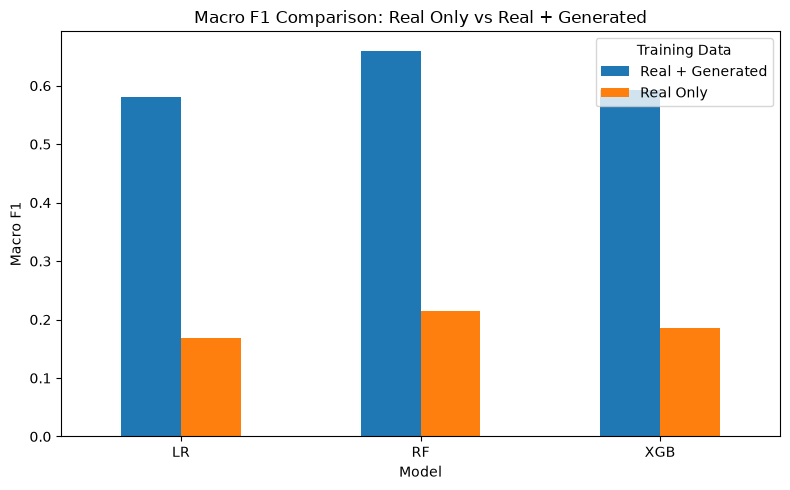

In [231]:
plot_data = experiment_comparison.pivot(
    index="Model",
    columns="Experiment",
    values="F1"
)

plot_data.plot(kind="bar", figsize=(8, 5))

plt.title("Macro F1 Comparison: Real Only vs Real + Generated")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=0)
plt.legend(title="Training Data")
plt.savefig('Visualization-image/Macro_F1_Comparison.png', dpi=300)
plt.tight_layout()
plt.show()

## Dummy Classifier Baseline

After training the machine learning models, we used a **Dummy Classifier** as a simple baseline for comparison.

The Dummy Classifier uses the `most_frequent` strategy, which means it always predicts the disease that appears most often in the training data. It does not learn relationships between the symptoms and the disease.

We tested it on the same real test set and calculated the same metrics: **Accuracy, Precision, Recall, and Macro F1**.

This provides a simple reference point for the trained models. Comparing their results with the Dummy Classifier helps us check whether the machine learning models are learning useful patterns from the features rather than simply predicting the most common disease.


In [232]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_real_train, y_real_train)
y_dummy_pred = dummy.predict(X_real_test)

dummy_results = {
    "Model": "Dummy",
    "Accuracy": accuracy_score(y_real_test, y_dummy_pred),
    "Precision": precision_score(y_real_test,y_dummy_pred,average="macro",zero_division=0),
    "Recall": recall_score(y_real_test,y_dummy_pred,average="macro",zero_division=0),
    "F1": f1_score(y_real_test,y_dummy_pred,average="macro",zero_division=0)
}

print(dummy_results)

{'Model': 'Dummy', 'Accuracy': 0.0594059405940594, 'Precision': 0.0012639561828523278, 'Recall': 0.02127659574468085, 'F1': 0.002386160270431497}


The Dummy Classifier achieved 5.9% accuracy and a very low Macro F1-score of 0.002.

This is expected because the Dummy Classifier does not learn any relationship between the features and the diseases. It simply predicts the most frequent disease for every record.

Compared with the real models, which achieved higher results, this shows that the models are learning more useful patterns from the data rather than only predicting the most common disease.

We will use the Dummy Classifier as a simple baseline to compare with the other models.


In [233]:
dummy_df = pd.DataFrame([dummy_results])
real_only_with_dummy = pd.concat([dummy_df, results_df],ignore_index=True)

print(real_only_with_dummy)

   Model  Accuracy  Precision    Recall        F1 Experiment
0  Dummy  0.059406   0.001264  0.021277  0.002386        NaN
1     LR  0.306931   0.172163  0.207447  0.169237  Real Only
2     RF  0.346535   0.212513  0.251773  0.214235  Real Only
3    XGB  0.267327   0.188045  0.230496  0.185191  Real Only


The Dummy Classifier provides a simple baseline, while LR, RF, and XGB are the actual machine learning models. This comparison helps us see how much better the models perform compared with simply predicting the most frequent disease.


## 5-Fold Cross Validation

#### Experiment 1: 5-Fold Cross Validation – Real Data Only

In this experiment, we used **5-Fold Stratified Cross Validation** on the real training data to check how consistent the models are across different splits of the data.

The training data was divided into five folds while keeping the class distribution balanced. Each time, four folds were used for training and one fold was used for validation. This was repeated five times.

We compared the models using **Accuracy, Precision, Recall, and Macro F1-score**. The original test set was kept separate and was not used during cross-validation.

In [234]:
# For Experiment 1
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

cv_results = []

for name, model in models.items():
    print(f"Running 5-Fold CV for {name}...")

    scores = cross_validate(
        model,
        X_real_train,
        y_real_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std()
    })

    cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

Running 5-Fold CV for LR...


/opt/anaconda3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples

Running 5-Fold CV for RF...


/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.14/site-packages/s

Running 5-Fold CV for XGB...


/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.14/site-packages/s

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,F1 Std
0,LR,0.297872,0.181859,0.240332,0.193005,0.030500
1,RF,0.310638,0.181503,0.251679,0.196794,0.036965
2,XGB,0.340426,0.210769,0.284718,0.226465,0.026370


#### Experiment 2: 5-Fold Cross Validation – Real + Generated Data

In this experiment, we also used **5-Fold Stratified Cross Validation**, but the folds were created using the real training data only.

For each fold, the generated data was added to the training part, while the validation part contained only real data. This allowed us to check whether adding generated data actually helps the models perform better on real unseen samples.

We evaluated the models using **Accuracy, Precision, Recall, and Macro F1-score**, while keeping the original test set separate for the final evaluation.


In [235]:
# For Experiment 2
from sklearn.base import clone

# Prepare generated data
X_generated_sample = generated_sample[cat_features + num_features + symptoms]
y_generated_sample = target_encoder.transform(generated_sample["Disease_Prediction"])

cv_combined_results = []

for name, model in models.items():

    fold_accuracy = []
    fold_precision = []
    fold_recall = []
    fold_f1 = []

    print(f"Running 5-Fold CV for {name} (Real + Generated)...")

    # Split ONLY the real training data into 5 folds
    for train_idx, val_idx in cv.split(X_real_train, y_real_train):

        # Real training and validation for this fold
        X_train_fold = X_real_train.iloc[train_idx]
        y_train_fold = y_real_train[train_idx]

        X_val_fold = X_real_train.iloc[val_idx]
        y_val_fold = y_real_train[val_idx]

        # Add generated data ONLY to training
        X_train_combined_fold = pd.concat([X_train_fold, X_generated_sample],ignore_index=True)
        y_train_combined_fold = np.concatenate([y_train_fold, y_generated_sample])

        # Train model
        fold_model = clone(model)
        fold_model.fit(X_train_combined_fold,y_train_combined_fold)

        # Validate ONLY on real data
        y_pred_fold = fold_model.predict(X_val_fold)

        fold_accuracy.append(accuracy_score(y_val_fold, y_pred_fold))
        fold_precision.append(
            precision_score(
                y_val_fold,
                y_pred_fold,
                average="macro",
                zero_division=0
            ))

        fold_recall.append(
            recall_score(
                y_val_fold,
                y_pred_fold,
                average="macro",
                zero_division=0
            ))

        fold_f1.append(
            f1_score(
                y_val_fold,
                y_pred_fold,
                average="macro",
                zero_division=0
            ))

    # Average of the 5 folds
    cv_combined_results.append({
        "Model": name,
        "CV Accuracy": np.mean(fold_accuracy),
        "CV Precision": np.mean(fold_precision),
        "CV Recall": np.mean(fold_recall),
        "CV F1": np.mean(fold_f1),
        "F1 Std": np.std(fold_f1)
    })

# Show results
cv_combined_results_df = pd.DataFrame(cv_combined_results)

display(cv_combined_results_df)

Running 5-Fold CV for LR (Real + Generated)...
Running 5-Fold CV for RF (Real + Generated)...
Running 5-Fold CV for XGB (Real + Generated)...


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,F1 Std
0,LR,0.514894,0.405584,0.482939,0.421250,0.072773
1,RF,0.625532,0.527129,0.601739,0.542085,0.053139
2,XGB,0.540426,0.452148,0.512172,0.460031,0.049772


#### Final Comparison: Experiment 1 vs. Experiment 2

The table below compares the cross-validation results from both experiments. **Experiment 1** uses only real data for training, while **Experiment 2** adds generated data to the training folds while keeping the validation data real.

This comparison helps us see whether adding generated data improves the models' performance and consistency across the five folds.


In [236]:
comparison_cv = pd.DataFrame({
    "Model": cv_results_df["Model"],

    "Real Only Accuracy": cv_results_df["CV Accuracy"],
    "Real + Generated Accuracy": cv_combined_results_df["CV Accuracy"],

    "Real Only F1": cv_results_df["CV F1"],
    "Real + Generated F1": cv_combined_results_df["CV F1"]
})

comparison_cv["F1 Improvement"] = (
    comparison_cv["Real + Generated F1"]
    - comparison_cv["Real Only F1"])

display(comparison_cv.round(3))

,Model,Real Only Accuracy,Real + Generated Accuracy,Real Only F1,Real + Generated F1,F1 Improvement
0,LR,0.298,0.515,0.193,0.421,0.228
1,RF,0.311,0.626,0.197,0.542,0.345
2,XGB,0.340,0.540,0.226,0.460,0.234


The figures below compare the Accuracy, Precision, Recall, and Macro F1-score of the three models across both experiments. This helps show the effect of adding generated data to the training set on the overall model performance.

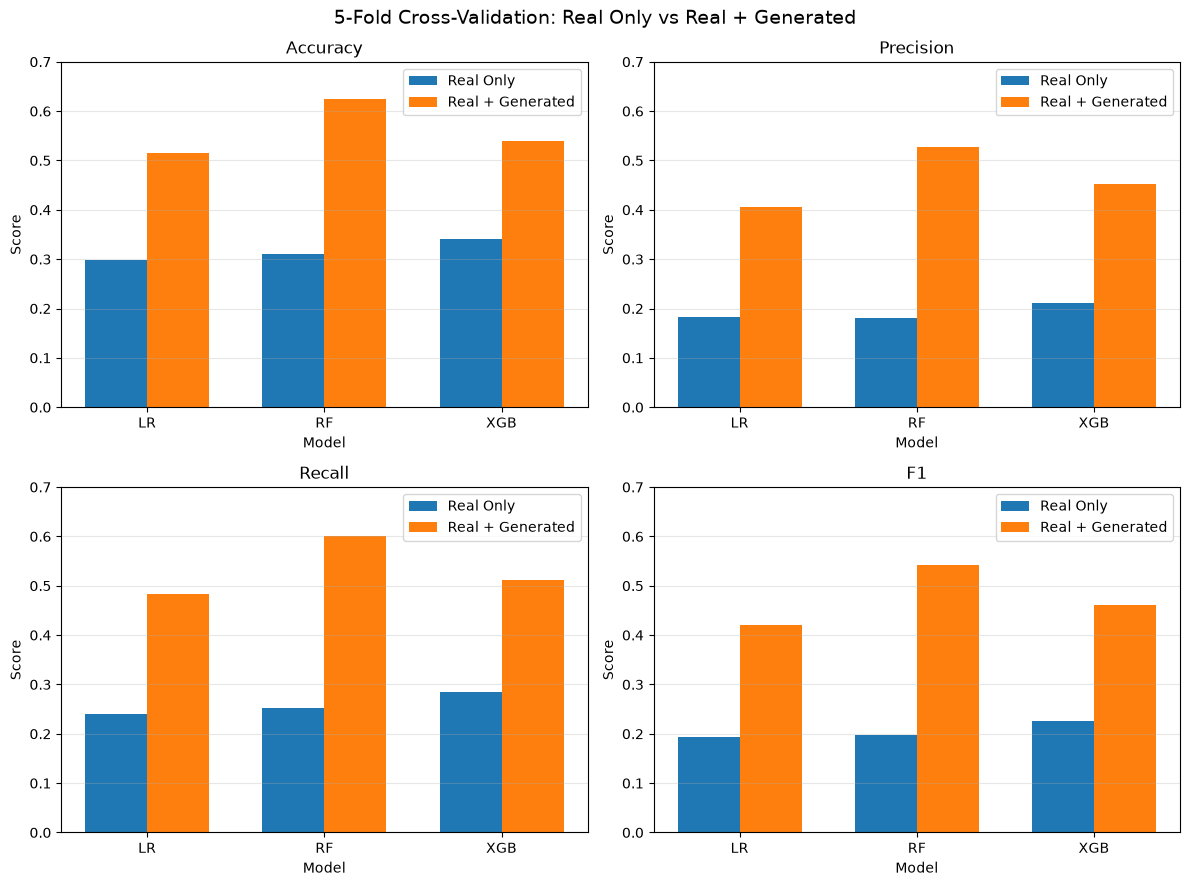

In [237]:
models_res = cv_results_df["Model"].tolist()
metrics = ["CV Accuracy", "CV Precision", "CV Recall", "CV F1"]

x = np.arange(len(models_res))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, metric in zip(axes.flatten(), metrics):

    exp1 = cv_results_df[metric]
    exp2 = cv_combined_results_df[metric]

    ax.bar(
        x - width/2,
        exp1,
        width,
        label="Real Only"
    )

    ax.bar(
        x + width/2,
        exp2,
        width,
        label="Real + Generated"
    )

    ax.set_title(metric.replace("CV ", ""))
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.set_xticks(x)
    ax.set_xticklabels(models_res)
    ax.set_ylim(0, 0.7)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

plt.suptitle(
    "5-Fold Cross-Validation: Real Only vs Real + Generated",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 	Real & Generated distribution

We compared the generated records with the real training data to check whether their feature distributions were reasonably consistent.

The target variable was intentionally balanced by selecting 15 generated samples for each of the 47 diseases. Therefore, its distribution differs from the imbalanced real data. This was done so that no disease would dominate after combining the real and generated data.

Most symptom proportions were similar to the real data. Some differences were observed in Age, Body Temperature, and Heart Rate, with Heart Rate also showing higher variability. Lethargy showed the largest symptom difference, while Fever, Weight Loss, and Swelling showed smaller differences.

Overall, the generated data showed reasonable similarity to the real data, with some differences identified and documented. The generated data was kept for the experiment where we added it to the real training data.

In [238]:
# For Features columns (x)

# 1. Define feature groups

numeric_features = [
    "Age",
    "Weight",
    "Body_Temperature",
    "Heart_Rate",
    "Duration_Days"
]

categorical_features = [
    "Animal_Type",
    "Gender"
]

binary_features = [
    "Appetite_Loss",
    "Vomiting",
    "Diarrhea",
    "Coughing",
    "Labored_Breathing",
    "Lameness",
    "Skin_Lesions",
    "Nasal_Discharge",
    "Eye_Discharge",
    "Reduced_Milk",
    "Reduced_Wool",
    "Swelling",
    "Fever",
    "Lethargy",
    "Weight_Loss",
    "Dehydration",
    "Sneezing"
]

# Convert to DataFrames
real_df = X_real_train.copy()
generated_df = generated_sample.drop(columns=["Disease_Prediction"],errors="ignore").copy()


# 2. Numeric feature comparison
numeric_comparison = pd.DataFrame({
    "Real Mean": real_df[numeric_features].mean(),
    "Generated Mean": generated_df[numeric_features].mean(),
    "Real Std": real_df[numeric_features].std(),
    "Generated Std": generated_df[numeric_features].std(),
    "Mean Difference": (
        generated_df[numeric_features].mean()
        - real_df[numeric_features].mean()
    )
})

display(numeric_comparison.round(2))


# 3. Binary symptom comparison
binary_comparison = pd.DataFrame({
    "Real (%)": real_df[binary_features].mean() * 100,
    "Generated (%)": generated_df[binary_features].mean() * 100
})

binary_comparison["Difference (pp)"] = (binary_comparison["Generated (%)"]- binary_comparison["Real (%)"])
display(binary_comparison.round(2))

# 4. Categorical comparison
for feature in categorical_features:

    real_dist = real_df[feature].value_counts(normalize=True) * 100
    generated_dist = generated_df[feature].value_counts(normalize=True) * 100

    comparison = pd.DataFrame({
        "Real (%)": real_dist,
        "Generated (%)": generated_dist
    }).fillna(0)

    comparison["Difference (pp)"] = (
        comparison["Generated (%)"]
        - comparison["Real (%)"]
    )

    print(f"\n===== {feature} =====")
    display(comparison.round(2))

,Real Mean,Generated Mean,Real Std,Generated Std,Mean Difference
Age,5.13,7.63,2.50,5.31,2.50
Weight,219.24,217.74,259.07,253.34,-1.50
Body_Temperature,39.30,39.91,0.31,1.03,0.61
Heart_Rate,105.03,120.58,27.13,66.89,15.55
Duration_Days,5.09,5.07,1.62,1.53,-0.03


,Real (%),Generated (%),Difference (pp)
Appetite_Loss,80.85,81.56,0.71
Vomiting,57.02,57.30,0.28
Diarrhea,54.47,54.33,-0.14
Coughing,69.36,69.08,-0.28
Labored_Breathing,57.87,55.89,-1.99
Lameness,60.85,60.99,0.14
Skin_Lesions,56.17,56.03,-0.14
Nasal_Discharge,47.23,47.09,-0.14
Eye_Discharge,54.04,54.18,0.14
Reduced_Milk,2.98,3.26,0.28



===== Animal_Type =====


,Real (%),Generated (%),Difference (pp)
Animal_Type,,,
Cat,14.47,17.59,3.12
Cow,17.02,14.04,-2.98
Dog,18.72,13.33,-5.39
Goat,10.21,8.23,-1.99
Horse,14.89,19.15,4.26
Pig,8.09,10.64,2.55
Rabbit,7.66,9.22,1.56
Sheep,8.94,7.80,-1.13



===== Gender =====


,Real (%),Generated (%),Difference (pp)
Gender,,,
Female,47.66,52.06,4.4
Male,52.34,47.94,-4.4


In [239]:
# For the disease Target (y)
real_dist = (
    pd.Series(y_real_train)
    .value_counts(normalize=True)
    .sort_index()
)

generated_dist = (
    pd.Series(y_generated_sample)
    .value_counts(normalize=True)
    .sort_index()
)

distribution_comparison = pd.DataFrame({
    "Real (%)": real_dist * 100,
    "Generated (%)": generated_dist * 100
}).fillna(0)

distribution_comparison["Difference (%)"] = (
    distribution_comparison["Generated (%)"] - distribution_comparison["Real (%)"]
)

display(distribution_comparison.round(2))

,Real (%),Generated (%),Difference (%)
0,2.13,2.13,0.00
1,3.40,2.13,-1.28
2,5.11,2.13,-2.98
3,1.28,2.13,0.85
4,4.68,2.13,-2.55
5,1.28,2.13,0.85
6,3.40,2.13,-1.28
7,1.28,2.13,0.85
8,2.13,2.13,0.00
9,4.26,2.13,-2.13


##  **Final Model Selection**
Looking at the comparison table across experiments, Random Forest trained on the Real + Generated data gave us the best results overall,it had the highest Macro F1-score and Accuracy compared to Logistic Regression and XGBoost, and this held true across both experiments (Real Only and Real + Generated). Because of this, we're going with this model (best_model) as our final choice. Next, we look more closely at its full classification report on the real test set that we never touched during training, to get a true picture of how it generalizes to unseen data.

In [240]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

# Pick the best (model, training_data) combination across ALL experiments
best_experiment = f1_comparison.stack().idxmax()
best_model_name = best_experiment[0]
training_data = best_experiment[1]   # the ACTUAL winning training data, not hardcoded

best_model = models[best_model_name]

print("Best experiment:", best_experiment)
print("Best model name:", best_model_name)
print("Training data:", training_data)

# Final predictions of the best model on the real, untouched test set
y_pred_best = best_model.predict(X_real_test)

final_summary = {
    "Model": best_model_name,
    "Training data": training_data,   # reflects what idxmax() actually found
    "Accuracy": accuracy_score(y_real_test, y_pred_best),
    "Precision (macro)": precision_score(y_real_test, y_pred_best, average="macro", zero_division=0),
    "Recall (macro)": recall_score(y_real_test, y_pred_best, average="macro", zero_division=0),
    "F1 (macro)": f1_score(y_real_test, y_pred_best, average="macro", zero_division=0),
}

print("\nFinal model summary:")
for k, v in final_summary.items():
    print(f"  {k}: {v}")

print("\nFull classification report:\n")
print(classification_report(
    y_real_test,
    y_pred_best,
    target_names=target_encoder.classes_,
    zero_division=0
))

Best experiment: ('RF', 'Real + Generated')
Best model name: RF
Training data: Real + Generated

Final model summary:
  Model: RF
  Training data: Real + Generated
  Accuracy: 0.7326732673267327
  Precision (macro): 0.6559777102330294
  Recall (macro): 0.7053191489361703
  F1 (macro): 0.6599797365754814

Full classification report:

                                    precision    recall  f1-score   support

    Actinobacillus Pleuropneumonia       1.00      1.00      1.00         2
                        Bluetongue       0.60      1.00      0.75         3
        Bovine Respiratory Disease       0.71      1.00      0.83         5
Bovine Respiratory Syncytial Virus       0.00      0.00      0.00         1
               Bovine Tuberculosis       0.67      0.40      0.50         5
             Bovine Viral Diarrhea       1.00      1.00      1.00         1
                  Canine Distemper       0.50      0.33      0.40         3
                  Canine Hepatitis       0.00      0.00 

The final Random Forest model (trained on Real + Generated data) achieved an accuracy of 72% and a macro F1-score of 65% on the untouched real test set. This gap between accuracy and macro F1 is expected given the nature of the dataset.

## Disease Confusion Analysis

We examined the incorrect predictions on the real test set to identify which diseases were most frequently confused by the model.

The model produced **25 different confusion pairs**. Most occurred only once, while the two most frequent confusions were **Canine Distemper → Parvovirus** and **Bovine Tuberculosis → Bovine Respiratory Disease**, with two cases each.

Several other errors occurred between diseases affecting the same animal type or having similar clinical characteristics, such as **Equine Arthritis and Equine Influenza**, or **Feline Herpesvirus and Feline Leukemia Virus**. These **do not represent the duplicate-label issue** addressed during data cleaning.

The previously identified duplicate or variant labels, such as **Bovine Respiratory Disease Complex, Bovine Mastitis, Canine Parvovirus, and Feline Panleukopenia**, were standardized before model training. Therefore, the remaining confusion patterns **do not provide evidence that duplicate target labels are limiting the model's recall**.


In [241]:
# Convert labels to strings
actual_names = np.array(y_real_test).astype(str)
predicted_names = np.array(y_pred_best).astype(str)

# Find incorrect predictions
wrong_mask = actual_names != predicted_names

confusions = pd.DataFrame({
    "Actual Disease": actual_names[wrong_mask],
    "Predicted Disease": predicted_names[wrong_mask]
})

# Count each type of confusion
confusion_counts = (
    confusions
    .value_counts()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

display(confusion_counts)

,Actual Disease,Predicted Disease,Count
0,4,2,2
1,6,36,2
13,17,20,1
23,17,13,1
22,18,19,1
21,11,10,1
20,15,21,1
19,15,16,1
18,7,36,1
17,8,36,1


In [242]:
# Show the disease names for the confusion pairs

confusion_counts_named = confusion_counts.copy()

confusion_counts_named["Actual Disease"] = target_encoder.inverse_transform(
    confusion_counts_named["Actual Disease"].astype(int)
)

confusion_counts_named["Predicted Disease"] = target_encoder.inverse_transform(
    confusion_counts_named["Predicted Disease"].astype(int)
)

display(confusion_counts_named)

,Actual Disease,Predicted Disease,Count
0,Bovine Tuberculosis,Bovine Respiratory Disease,2
1,Canine Distemper,Parvovirus,2
13,Equine Influenza,Equine Rhinopneumonitis,1
23,Equine Influenza,Equine Arthritis,1
22,Equine Laminitis,Equine Protozoal Myeloencephalitis,1
21,Caprine Respiratory Disease,Caprine Pleuropneumonia,1
20,Equine Herpesvirus,Equine West Nile Virus,1
19,Equine Herpesvirus,Equine Infectious Anemia,1
18,Canine Hepatitis,Parvovirus,1
17,Canine Leptospirosis,Parvovirus,1


In [243]:
# Investigation of the most Confusion Pairs
pairs = [
    ["Canine Distemper", "Parvovirus"],
    ["Bovine Tuberculosis", "Bovine Respiratory Disease"]
]

check_features = [
    "Animal_Type",
    "Age",
    "Weight",
    "Appetite_Loss",
    "Vomiting",
    "Diarrhea",
    "Coughing",
    "Labored_Breathing",
    "Lameness",
    "Skin_Lesions",
    "Nasal_Discharge",
    "Eye_Discharge",
    "Body_Temperature",
    "Heart_Rate",
    "Fever",
    "Lethargy",
    "Weight_Loss",
    "Dehydration",
    "Sneezing",
    "Duration_Days"
]

for pair in pairs:
    print("=" * 90)
    print(f"{pair[0]} vs {pair[1]}")
    print("=" * 90)

    # REAL DATA
    real_pair = real_train[
        real_train["Disease_Prediction"].isin(pair)
    ]

    print("\nREAL DATA:")
    display(
        real_pair[["Disease_Prediction"] + check_features]
        .groupby("Disease_Prediction")
        .mean(numeric_only=True)
        .round(2)
    )

    print("\nREAL ANIMAL TYPE:")
    display(
        pd.crosstab(
            real_pair["Disease_Prediction"],
            real_pair["Animal_Type"],
            normalize="index"
        ).round(2)
    )

    # GENERATED DATA
    generated_pair = generated_sample[
        generated_sample["Disease_Prediction"].isin(pair)
    ]

    print("\nGENERATED DATA:")
    display(
        generated_pair[["Disease_Prediction"] + check_features]
        .groupby("Disease_Prediction")
        .mean(numeric_only=True)
        .round(2)
    )

    print("\nGENERATED ANIMAL TYPE:")
    display(
        pd.crosstab(
            generated_pair["Disease_Prediction"],
            generated_pair["Animal_Type"],
            normalize="index"
        ).round(2)
    )

Canine Distemper vs Parvovirus

REAL DATA:


,Age,Weight,Appetite_Loss,Vomiting,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Fever,Lethargy,Weight_Loss,Dehydration,Sneezing,Duration_Days
Disease_Prediction,,,,,,,,,,,,,,,,,,,
Canine Distemper,5.25,23.62,1.00,0.38,0.62,0.88,0.50,0.50,0.62,0.75,0.38,39.30,122.50,0.88,0.88,0.0,0.00,0.0,4.62
Parvovirus,4.79,23.43,0.86,0.43,0.57,0.57,0.43,0.64,0.50,0.14,0.14,39.21,124.71,0.50,0.93,0.0,0.14,0.0,4.07



REAL ANIMAL TYPE:


Animal_Type,Dog
Disease_Prediction,
Canine Distemper,1.0
Parvovirus,1.0



GENERATED DATA:


...

Animal_Type,Cow
Disease_Prediction,
Bovine Respiratory Disease,1.0
Bovine Tuberculosis,1.0



GENERATED DATA:


,Age,Weight,Appetite_Loss,Vomiting,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Fever,Lethargy,Weight_Loss,Dehydration,Sneezing,Duration_Days
Disease_Prediction,,,,,,,,,,,,,,,,,,,
Bovine Respiratory Disease,6.13,520.25,0.8,0.6,0.53,0.8,0.73,0.53,0.60,0.27,0.73,40.51,87.47,1.0,0.8,0.13,0.0,0.0,5.53
Bovine Tuberculosis,6.00,553.27,1.0,0.2,0.87,0.2,0.87,0.80,0.33,0.33,0.40,39.39,69.80,0.4,1.0,0.53,0.0,0.0,6.00



GENERATED ANIMAL TYPE:


Animal_Type,Cow
Disease_Prediction,
Bovine Respiratory Disease,1.0
Bovine Tuberculosis,1.0


In [244]:
for disease in [
    "Canine Distemper",
    "Parvovirus",
    "Bovine Tuberculosis",
    "Bovine Respiratory Disease"
]:
    print(
        disease,
        "Real:",
        (test_pool["Disease_Prediction"] == disease).sum(),
        "Generated:",
        (generated_sample["Disease_Prediction"] == disease).sum()
    )

Canine Distemper Real: 11 Generated: 15
Parvovirus Real: 20 Generated: 15
Bovine Tuberculosis Real: 16 Generated: 15
Bovine Respiratory Disease Real: 17 Generated: 15


**Investigation of Main Disease Confusions** :

We investigated the two most frequent errors: **Canine Distemper → Parvovirus** and **Bovine Tuberculosis → Bovine Respiratory Disease**, by comparing the real training data with the generated data used for training.

For **Canine Distemper and Parvovirus**, the generated data preserved several important patterns from the real data, including similar symptom distributions and the distinction in **nasal discharge, eye discharge, and fever**. Therefore, there is no strong evidence that the generated data caused this confusion.

For **Bovine Tuberculosis and Bovine Respiratory Disease**, some differences were observed between the real and generated data, particularly for **labored breathing, fever, coughing, and weight loss** in Bovine Tuberculosis. However, the generated records still contain meaningful differences between the two diseases, so we cannot conclude that the generated data directly caused the model's errors.

Overall, the investigation does **not support changing or merging the disease labels**. The errors are better treated as classification errors between separate diseases with overlapping clinical features. The results also show that the generated data is reasonably useful for increasing the training samples, while its limitations should be acknowledged.


## Feature Importance
Now that we compared the models, we look inside the best-performing model (Random Forest, trained on Real + Generated data) to understand which features contributed most to its predictions.
Since the model was trained through a **Pipeline** (preprocessing + model), we first need to recover the feature names after preprocessing (after scaling, one-hot encoding, and passthrough of the symptom columns), and then match them with the **feature_importances_** learned by the Random Forest.
This step helps us understand which symptoms, vitals, or categorical features are the most influential in predicting the disease.

In [245]:
best_model_name = f1_comparison["Real + Generated"].idxmax()
best_model = models[best_model_name]

print("Best model based on Macro F1 (Real + Generated):", best_model_name)
preprocessor = best_model.named_steps["prep"]
feature_names = preprocessor.get_feature_names_out()
model_step = best_model.named_steps["model"]
importances = model_step.feature_importances_

feat_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feat_importance_df = feat_importance_df.sort_values("Importance", ascending=False)
feat_importance_df = feat_importance_df.reset_index(drop=True)

print(feat_importance_df.head(20))

Best model based on Macro F1 (Real + Generated): RF
                        Feature  Importance
0                   num__Weight    0.089666
1               num__Heart_Rate    0.086509
2         num__Body_Temperature    0.070511
3            num__Duration_Days    0.068302
4                      num__Age    0.057243
5            symptoms__Lameness    0.045125
6            symptoms__Vomiting    0.044742
7       symptoms__Eye_Discharge    0.044381
8   symptoms__Labored_Breathing    0.043928
9            symptoms__Diarrhea    0.043636
10    symptoms__Nasal_Discharge    0.039655
11       symptoms__Skin_Lesions    0.036599
12           symptoms__Coughing    0.032277
13              symptoms__Fever    0.029495
14           symptoms__Lethargy    0.026105
15      symptoms__Appetite_Loss    0.026042
16         cat__Animal_Type_Pig    0.018168
17         cat__Animal_Type_Dog    0.018016
18           cat__Gender_Female    0.017064
19        symptoms__Weight_Loss    0.017048


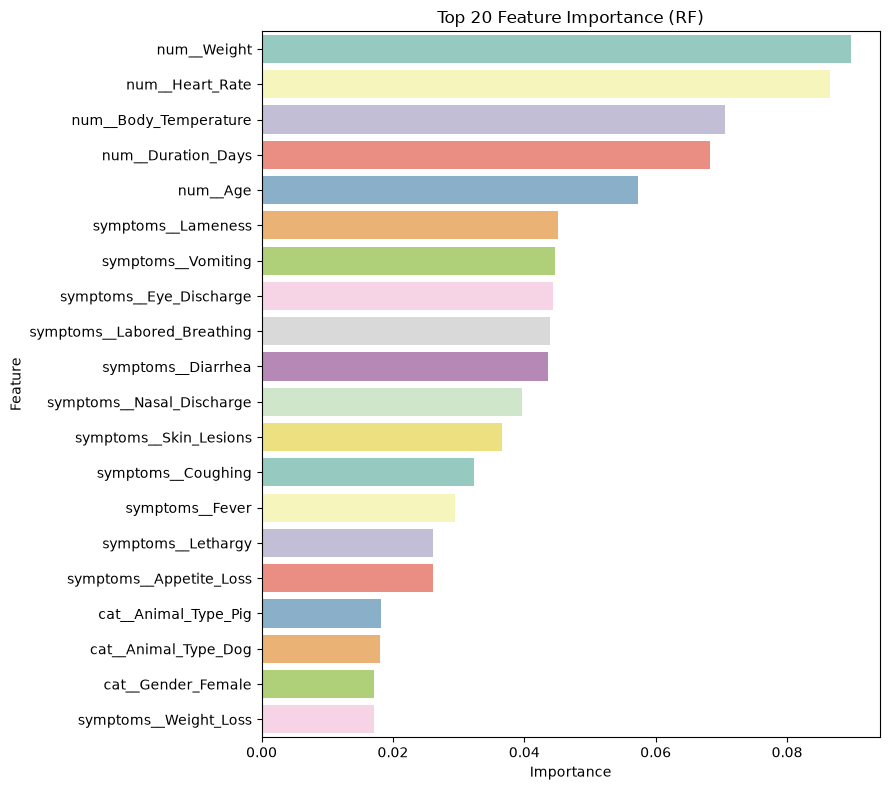

In [246]:
# Plot the Top 20 most important features
plt.figure(figsize=(9, 8))
top_features = feat_importance_df.head(20)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette='Set3'
)
plt.title(f"Top 20 Feature Importance ({best_model_name})")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig('Visualization-image/Feature_Importance.png', dpi=300)
plt.tight_layout()
plt.show()

The plot shows that numeric (**vital sign**) features are the most influential in the model's predictions, with **Weight**, **Heart_Rate**, and **Body_Temperature** ranking as the **top 3**, followed by **Duration_Days** and **Age**. This makes sense since these measurements tend to vary noticeably depending on the disease.

Right after the numeric features, we see a cluster of symptom features as **Lameness**, **Vomiting**, **Labored_Breathing**, **Eye_Discharge**, and **Diarrhea** with fairly close importance scores.

On the other hand, categorical features like **Animal_Type** and **Gender** have relatively low importance compared to the rest, meaning the animal's type or gender contributes much less to the prediction than the vitals and symptoms do.

## Screening Tool

Here we build a simple screening tool on top of the final model: given the animal's basic info, vitals, and symptoms, it returns the top predicted diseases with their probabilities basically how SymptoScan would be used for early screening in practice.

In [247]:
def predict_disease(input_dict, top_k=3):
    """
    input_dict must contain:
      - Animal_Type, Gender                         (categorical)
      - Age, Weight, Heart_Rate,
        Body_Temperature, Duration_Days              (numeric)
      - one 0/1 (or True/False) entry for every symptom in `symptoms`

    Returns a list of (disease_name, probability) tuples, sorted from
    most to least likely, of length `top_k`.
    """
    row = {col: input_dict.get(col, 0) for col in symptoms}
    row.update({col: input_dict[col] for col in cat_features + num_features})

    X_new = pd.DataFrame([row])[cat_features + num_features + symptoms]

    probs = best_model.predict_proba(X_new)[0]
    top_idx = np.argsort(probs)[::-1][:top_k]

    diseases = target_encoder.inverse_transform(top_idx)
    return list(zip(diseases, probs[top_idx]))


def screen_animal():
    """Interactive command-line style screening using the trained model."""
    print("=== SymptoScan Screening Tool ===\n")

    animal_type = input(f"Animal type {sorted(df_copy['Animal_Type'].unique())}: ").strip()
    gender = input(f"Gender {sorted(df_copy['Gender'].unique())}: ").strip()
    age = float(input("Age: "))
    weight = float(input("Weight: "))
    heart_rate = float(input("Heart rate: "))
    body_temperature = float(input("Body temperature (°C): "))
    duration_days = float(input("Duration of symptoms (days): "))

    print("\nAnswer 1 for yes, 0 for no:")
    symptom_answers = {}
    for s in symptoms:
        val = input(f"  {s.replace('_', ' ')}? ").strip()
        symptom_answers[s] = 1 if val in ("1", "y", "yes", "true") else 0

    input_dict = {
        "Animal_Type": animal_type,
        "Gender": gender,
        "Age": age,
        "Weight": weight,
        "Heart_Rate": heart_rate,
        "Body_Temperature": body_temperature,
        "Duration_Days": duration_days,
        **symptom_answers,
    }

    predictions = predict_disease(input_dict, top_k=3)

    print("\n Top 3 predicted diseases:")
    for disease, prob in predictions:
        print(f"  {disease}: {prob:.1%}")

    return predictions

In [248]:
# For example using one real record from the untouched test set
example_row = real_test.iloc[4]

example_input = {
    "Animal_Type": example_row["Animal_Type"],
    "Gender": example_row["Gender"],
    "Age": example_row["Age"],
    "Weight": example_row["Weight"],
    "Heart_Rate": example_row["Heart_Rate"],
    "Body_Temperature": example_row["Body_Temperature"],
    "Duration_Days": example_row["Duration_Days"],
    **{s: example_row[s] for s in symptoms},
}

print("Actual disease:", example_row["Disease_Prediction"])
print("\nModel's top 3 predictions:")
for disease, prob in predict_disease(example_input, top_k=3):
    print(f"  {disease}: {prob:.1%}")

Actual disease: Pneumonia

Model's top 3 predictions:
  Pneumonia: 80.0%
  Pasteurellosis: 10.3%
  Caprine Arthritis Encephalitis: 2.7%


The screening tool predicted Pneumonia as the most likely disease with an estimated probability of 80.0%, followed by Pasteurellosis (10.3%) and Caprine Arthritis Encephalitis (2.7%).

 ## **Saving the Model**
 Now that we've selected and evaluated our final model (Random Forest trained on Real + Generated data), the last step is to save everything needed to reuse this model later — without having to retrain it from scratch. This is especially important if we want to deploy the model in an app, an API, or simply load it in a different notebook/session.

In [249]:
import joblib

joblib.dump(best_model, "symptoscan_best_model.pkl")
joblib.dump(target_encoder, "symptoscan_label_encoder.pkl")

joblib.dump({
    "cat_features": cat_features,
    "num_features": num_features,
    "symptoms": symptoms,
    "best_model_name": best_model_name,
}, "symptoscan_metadata.pkl")

print("Saved files:")
print(" - symptoscan_best_model.pkl   (full sklearn Pipeline: preprocessing + model)")
print(" - symptoscan_label_encoder.pkl (LabelEncoder for Disease_Prediction)")
print(" - symptoscan_metadata.pkl      (feature lists)")

Saved files:
 - symptoscan_best_model.pkl   (full sklearn Pipeline: preprocessing + model)
 - symptoscan_label_encoder.pkl (LabelEncoder for Disease_Prediction)
 - symptoscan_metadata.pkl      (feature lists)


We use **joblib** to save three files:

**symptoscan_best_model.pkl -** the full Pipeline (preprocessing + model), so new data automatically goes through the same scaling/encoding.

**symptoscan_label_encoder.pkl -** the LabelEncoder to decode predictions back into disease names.

**symptoscan_metadata.pkl -** feature lists (categorical, numeric, symptoms), and the best model's name, all needed to correctly format new inputs later.

In [250]:
loaded_model = joblib.load("symptoscan_best_model.pkl")
loaded_encoder = joblib.load("symptoscan_label_encoder.pkl")

reloaded_pred = loaded_encoder.inverse_transform(loaded_model.predict(X_real_test))
original_pred = target_encoder.inverse_transform(best_model.predict(X_real_test))

print("Reloaded model predictions match original:", (reloaded_pred == original_pred).all())

Reloaded model predictions match original: True


This step verifies that the saved model works correctly after being reloaded from disk. Comparing predictions from the reloaded model against the original model's predictions on the same test set confirms that saving and loading with joblib preserved the model exactly, with no loss or change in behavior.

## **Conclusion**
**1. Project goal**
SymptoScan is an AI-based system that predicts an animal's disease using its basic information (type, gender, age, weight), vital signs (heart rate, body temperature, symptom duration), and symptoms, with the goal of supporting early disease screening.

**2. Data sources**
Two datasets were used: a real dataset from Kaggle (431 records, 22 columns), and an AI-generated dataset (10,031 records) that was later used only to expand the training data.

**3. Data cleaning**
The Breed column was dropped (too many categories relative to the dataset size), duplicate rows were removed, column types were fixed (symptoms converted to boolean, body temperature to float, duration to number of days), and the scattered symptom text columns were standardized.

**4. Unifying disease names**
There were originally 139 disease names containing duplicates (the same disease written in different formats), so a mapping dictionary (**disease_mapping**) was used to unify them into 113 unique names. This improved classification quality, since duplicate labels were splitting the already limited data across more classes than necessary.

**5. Filtering rare classes**
Only diseases with at least 3 real records were kept (to ensure a reliable evaluation), which reduced the number of classes actually used for training and testing to 47 diseases (out of 336 records). This pool was split into 235 training records and 101 test records using a stratified split.

**6. A simple baseline for comparison**
A Dummy Classifier (always predicting the most frequent disease) was trained as a lower-bound reference point, to show that the real models (LR, RF, XGB) were actually learning a meaningful relationship between the data and the disease, not just guessing randomly.

**7. Two experiments for comparison**
Three models (Logistic Regression, Random Forest, and XGBoost) were trained in two experiments: the first on real data only, and the second after adding 705 generated records (15 per class) to the training data only, while keeping the test set fully real and untouched.

**8. Best result**
The results showed that adding generated data improved the performance of all three models, and Random Forest trained on Real + Generated data performed best, with 73.2% accuracy and a 0.659 Macro F1-score, outperforming XGBoost (64.3%, 0.591) and Logistic Regression (59.4%, 0.581).

**9. Model interpretation**
A feature importance analysis was done on the best model (RF), showing that symptoms and vital signs (like temperature and heart rate) had a bigger influence than categorical features (animal type and gender) on the model's decisions, which makes clinical sense.

**10. Final deliverable**
The best model was selected automatically based on the highest F1-score, and saved along with the LabelEncoder and the feature lists using joblib. A screening tool (**predict_disease** and **screen_animal**) was also built to test the model practically, as a first step toward building a real user interface (Streamlit) on top of this saved model.